<a href="https://colab.research.google.com/github/NishaSharma077/EduPro-Learner-Analytics/blob/main/EduPro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Learner Demographics and Course Enrollment Behavior Analysis on EduPro**

# import libraries and csv files

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')


course = pd.read_csv('//content/drive/MyDrive/EduPro Online Platform.xlsx - Courses.csv')
user = pd.read_csv('//content/drive/MyDrive/EduPro Online Platform.xlsx - Users.csv')
transaction = pd.read_csv('//content/drive/MyDrive/EduPro Online Platform.xlsx - Transactions.csv')
course.head()
user.head()
transaction.head()




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,25/10/2025,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,13/1/2025,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,28/3/2025,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2/6/2025,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,10/8/2025,0.0,PayPal,TC00042


In [4]:
user.info()
course.info()
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CourseID        60 non-null     object 
 1   CourseName      60 non-null     object 
 2   CourseCategory  60 non-null     object 
 3   CourseType      60 non-null     object 
 4   CourseLevel     60 non-null     object 
 5   CoursePrice     60 non-null     float64
 6   CourseDuration  60 non-null     float64
 7   CourseRating    60 non-null     float64
dtypes: float64(3), obje

In [5]:
user.shape
course.shape
transaction.shape

(10000, 7)

In [6]:

user.index
course.index
transaction.index

RangeIndex(start=0, stop=10000, step=1)

In [7]:
user.columns
course.columns
transaction.columns

Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID'],
      dtype='object')

In [8]:
user.describe()
course.describe()
transaction.describe()

,Amount
count,10000.000000
mean,91.132347
std,152.063524
min,0.000000
25%,0.000000
50%,0.000000
75%,119.040000
max,490.900000


# **Checking missing value or duplicates**

In [9]:
user.isnull().sum()
course.isnull().sum()
transaction.isnull().sum()

,0
TransactionID,0
UserID,0
CourseID,0
TransactionDate,0
Amount,0
PaymentMethod,0
TeacherID,0


In [10]:
user.duplicated().sum()
course.duplicated().sum()
transaction.duplicated().sum()

np.int64(0)

## There are no missing values and no duplicates in all files (User, course, transaction)

# **Merge the table**

In [11]:
df = transaction.merge(user,on="UserID")
df = df.merge(course,on="CourseID")
df.head(1000)

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,Age,Gender,Email,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,TT00001,U00003,CR00016,25/10/2025,0.00,PayPal,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,Digital Marketing,Marketing,Free,Intermediate,0.00,42.68,4.72
1,TT00002,U00003,CR00037,13/1/2025,0.00,PayPal,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,Scrum Essentials,Project Management,Free,Intermediate,0.00,33.93,3.45
2,TT00003,U00003,CR00019,28/3/2025,0.00,Bank Transfer,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,Content Marketing,Marketing,Free,Advanced,0.00,18.00,2.98
3,TT00004,U00004,CR00048,2/6/2025,0.00,Bank Transfer,TC00040,fthornton,23,Female,christensencatherine@outlook.com,AI Ethics,Artificial Intelligence,Free,Beginner,0.00,42.70,3.64
4,TT00005,U00004,CR00060,10/8/2025,0.00,PayPal,TC00042,fthornton,23,Female,christensencatherine@outlook.com,Content Creation,Digital Marketing,Free,Beginner,0.00,8.95,2.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,TT00996,U01586,CR00030,14/12/2025,0.00,PayPal,TC00042,bobby05,27,Male,garrett72@hotmail.com,Reinforcement Learning,Machine Learning,Free,Intermediate,0.00,38.49,1.73
996,TT00997,U01586,CR00036,15/3/2025,0.00,PayPal,TC00042,bobby05,27,Male,garrett72@hotmail.com,Agile Project Management,Project Management,Free,Beginner,0.00,15.75,4.68
997,TT00998,U01586,CR00022,30/1/2025,0.00,Credit Card,TC00040,bobby05,27,Male,garrett72@hotmail.com,Data Visualization,Data Science,Free,Beginner,0.00,32.64,3.65
998,TT00999,U01586,CR00039,12/8/2025,346.71,PayPal,TC00040,bobby05,27,Male,garrett72@hotmail.com,Project Planning,Project Management,Paid,Advanced,346.71,3.42,1.23


**Create age group**

In [12]:
bins = [0, 18, 25, 35, 45, 100]
labels = ['0-18', '19-25', '26-35', '36-45', '46+']

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)
df["AgeGroup"].value_counts()
age_counts = df["AgeGroup"].value_counts().sort_index()
age_counts

,count
AgeGroup,
0-18,1469
19-25,3272
26-35,4820
36-45,439
46+,0


# **What is the age distribution?**

<function matplotlib.pyplot.show(close=None, block=None)>

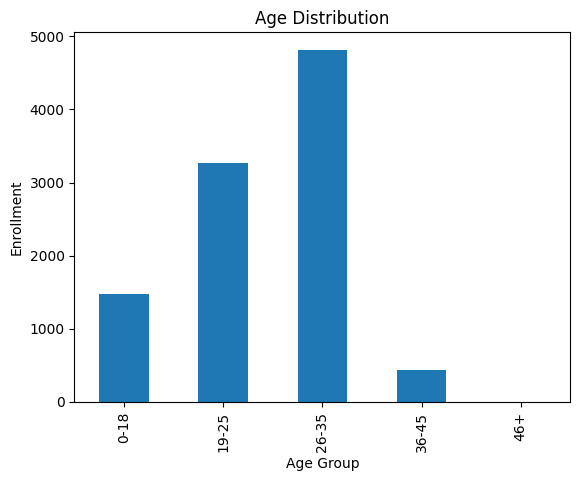

In [13]:
age_counts.plot (kind = 'bar')
plt.xlabel('Age Group')
plt.ylabel('Enrollment')
plt.title('Age Distribution')
plt.show

# **Gender Distribution**

<function matplotlib.pyplot.show(close=None, block=None)>

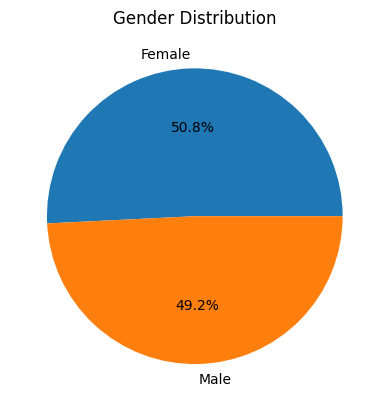

In [14]:
gender = df['Gender'].value_counts()
gender.plot(kind='pie', autopct="%1.1f%%")
plt.ylabel('')
plt.title('Gender Distribution')
plt.show

# **Course Category Popularity**

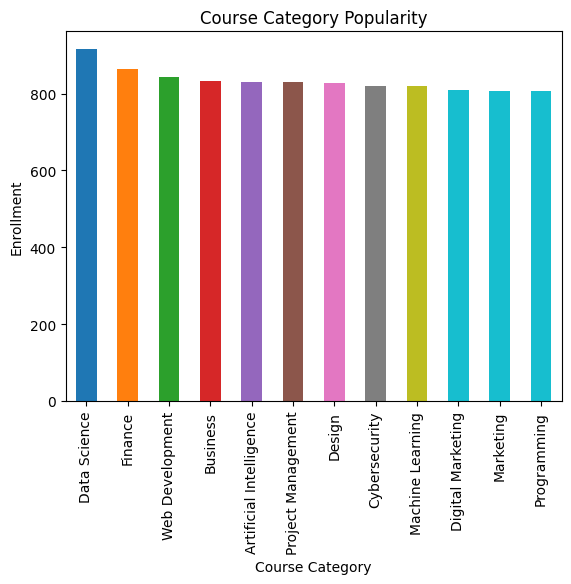

In [15]:
Category = df['CourseCategory'].value_counts()
Category

Category.plot(
    kind='bar',
    color=plt.cm.tab10(range(len(Category)))
)

plt.xlabel('Course Category')
plt.ylabel('Enrollment')
plt.title('Course Category Popularity')
plt.show()


# **Course Type Popularity**

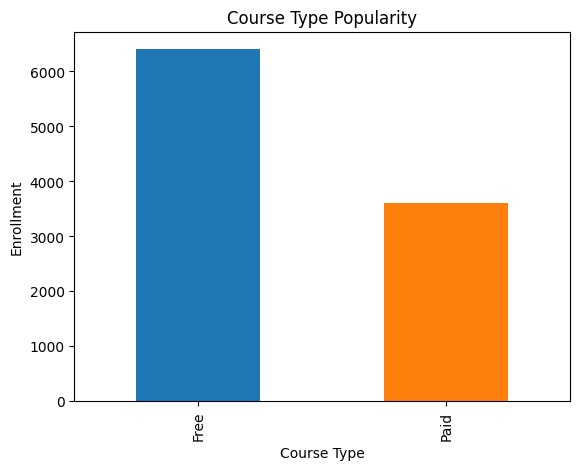

In [16]:
coursetype = df['CourseType'].value_counts()
coursetype

coursetype.plot(
    kind='bar',
    color=plt.cm.tab10(range(len(coursetype)))
)

plt.xlabel('Course Type')
plt.ylabel('Enrollment')
plt.title('Course Type Popularity')
plt.show()

# **Course Level Popularity**

<function matplotlib.pyplot.show(close=None, block=None)>

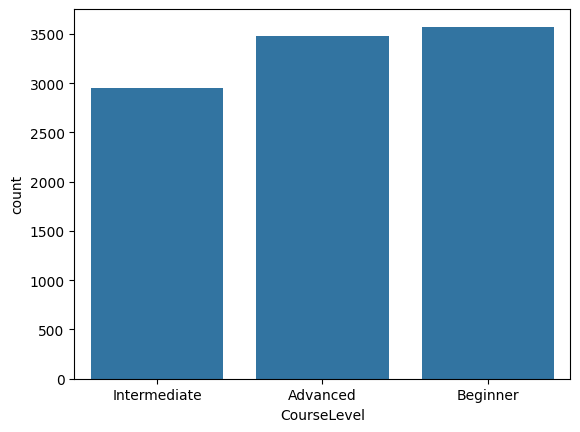

In [17]:
courselevel = df['CourseLevel'].value_counts()
courselevel

sns.countplot(data=df, x='CourseLevel')
plt.show

# **Age Group vs Category**

In [18]:
pivot = pd.crosstab(
    df['AgeGroup'],
    df['CourseCategory']
)

pivot

CourseCategory,Artificial Intelligence,Business,Cybersecurity,Data Science,Design,Digital Marketing,Finance,Machine Learning,Marketing,Programming,Project Management,Web Development
AgeGroup,,,,,,,,,,,,
0-18,129,120,121,114,120,127,136,120,126,109,115,132
19-25,276,265,278,300,272,263,259,263,275,274,260,287
26-35,391,415,381,464,395,385,435,395,378,386,408,387
36-45,33,33,39,38,40,33,34,41,27,37,46,38


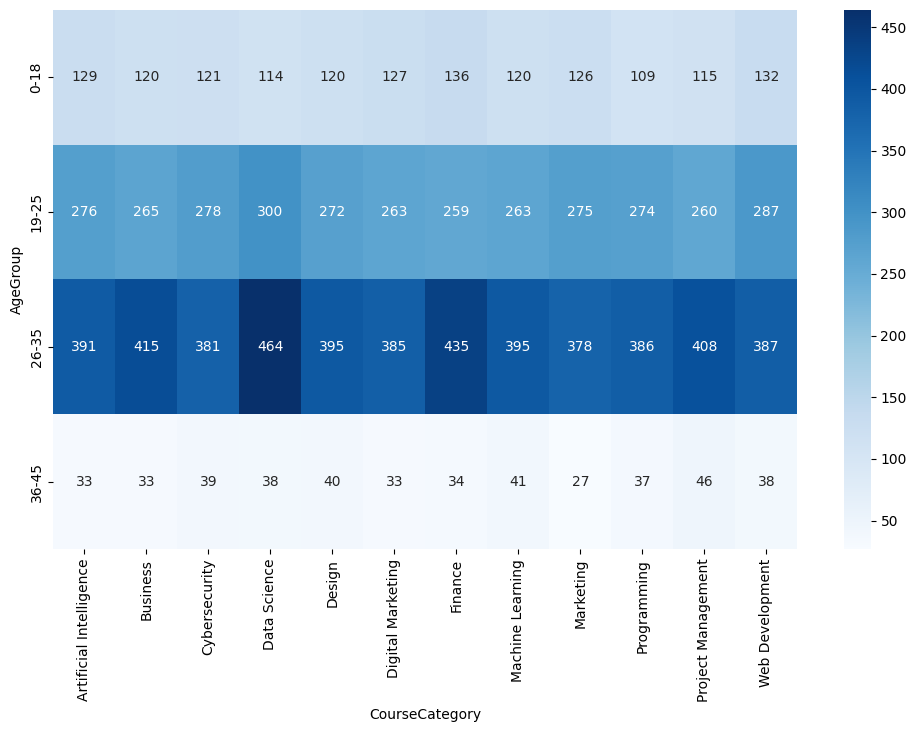

In [19]:
plt.figure(figsize=(12,7))

sns.heatmap(
    pivot,
    annot=True,
    cmap="Blues",
    fmt='d'
)

plt.show()

# **Gender v/s Course Level**

In [20]:
gender_level = pd.crosstab(
    df['Gender'],
    df['CourseLevel']
)

gender_level

CourseLevel,Advanced,Beginner,Intermediate
Gender,,,
Female,1758,1811,1509
Male,1717,1762,1443


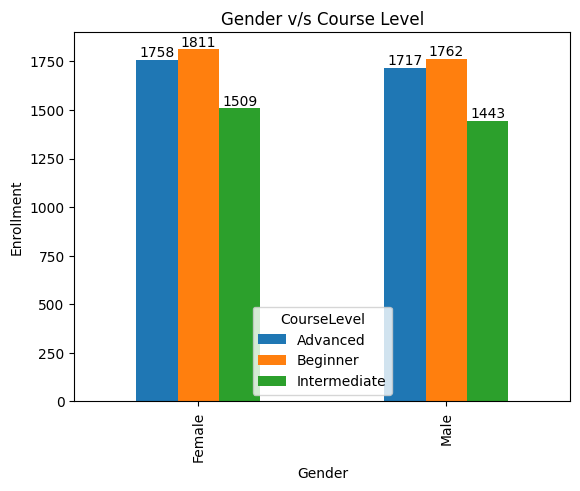

In [21]:
ax = gender_level.plot(
    kind='bar',
)

# Add data labels
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])

plt.xlabel('Gender')
plt.ylabel('Enrollment')
plt.title('Gender v/s Course Level')

plt.show()



# **Average Courses per Learner**

In [22]:
courses_per_user = df.groupby('UserID')['CourseID'].nunique()
average_courses_per_user = courses_per_user.mean()
average_courses_per_user

np.float64(3.3333333333333335)

# **Most Active Learners**

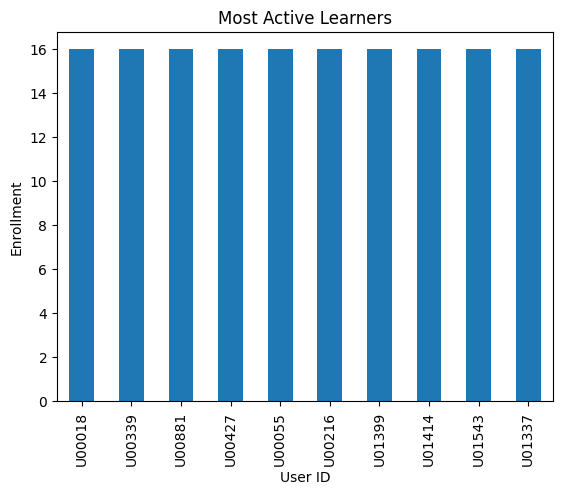

In [23]:
top_users = df['UserID'].value_counts().head(10)
top_users

top_users.plot(
    kind='bar',
)

plt.xlabel('User ID')
plt.ylabel('Enrollment')
plt.title('Most Active Learners')
plt.show()


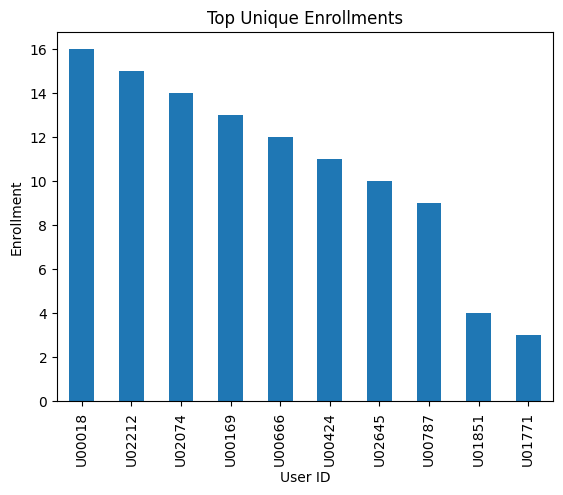

In [24]:
#top unique enrollment
top_users = df["UserID"].value_counts()

top_unique = top_users.drop_duplicates().head(10)

top_unique.plot(kind="bar")
plt.xlabel("User ID")
plt.ylabel("Enrollment")
plt.title("Top Unique Enrollments")
plt.show()

# **Beginner vs Advanced**

In [25]:
level_age = pd.crosstab(
    df['CourseLevel'],
    df['AgeGroup']
)

level_age

AgeGroup,0-18,19-25,26-35,36-45
CourseLevel,,,,
Advanced,534,1139,1649,153
Beginner,501,1184,1737,151
Intermediate,434,949,1434,135


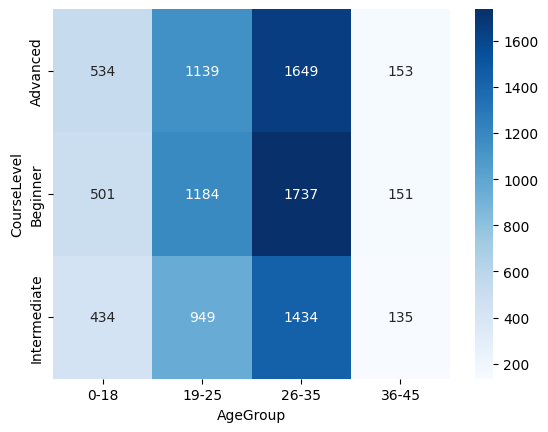

In [26]:
sns.heatmap(
    level_age,
    annot=True,
    cmap="Blues",
    fmt='d'
)

plt.show()


# **KPI Calculations**

## Total Learners

In [27]:
total_user = df['UserID'].nunique()
total_user


3000

## Total Courses

In [28]:
total_course = df['CourseID'].nunique()
total_course

60

## Total Enrollments

In [29]:
total_enrollment = len(df)

### Average Courses per Learner

In [30]:
avg = df.groupby('UserID').size().mean()
avg

np.float64(3.3333333333333335)

## Most Popular Category

In [31]:
df['CourseCategory'].value_counts().idxmax()

'Data Science'

## Most Popular Level

In [32]:
df['CourseLevel'].value_counts().idxmax()

'Beginner'

# **Streamlit Dashboard (app.py)**

In [33]:
!pip install -q streamlit
!pkill -f streamlit
!pkill -f cloudflared

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 50.3 MB/s eta 0:00:00


2026-07-24 23:43:11.448 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 23:43:11.450 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-24 23:43:11.452 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-24 23:43:11.455 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 23:43:11.525 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 23:43:11.684 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-24 23:43:11.685 Thread 'MainThread': mi

DeltaGenerator()

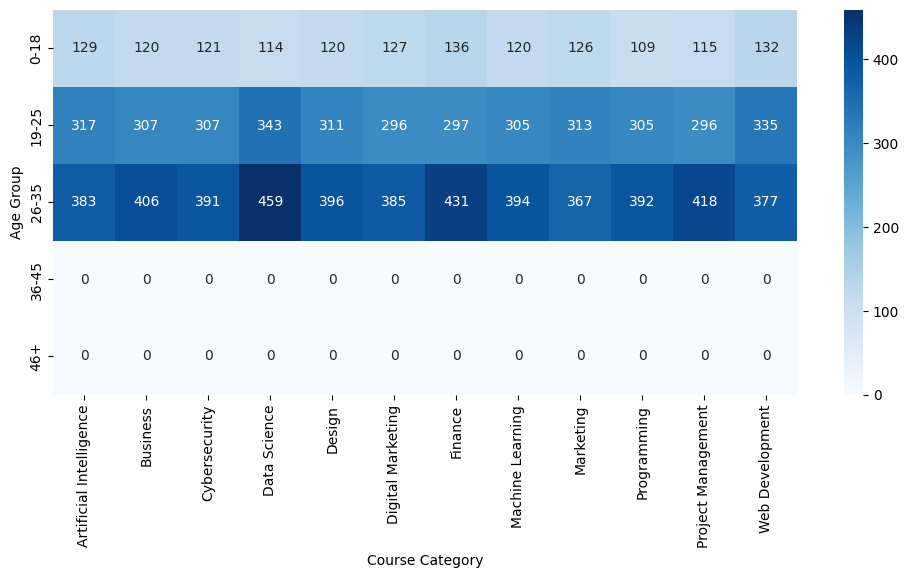

In [34]:

import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="EduPro Learner Analytics",
    page_icon="📊",
    layout="wide"
)

# =========================================================
# LOAD DATA
# =========================================================

@st.cache_data
def load_data():

    course = pd.read_csv(
        "//content/drive/MyDrive/EduPro Online Platform.xlsx - Courses.csv"
    )

    user = pd.read_csv(
        "//content/drive/MyDrive/EduPro Online Platform.xlsx - Users.csv"
    )

    transaction = pd.read_csv(
        "//content/drive/MyDrive/EduPro Online Platform.xlsx - Transactions.csv"
    )

    # Remove accidental spaces
    course.columns = course.columns.str.strip()
    user.columns = user.columns.str.strip()
    transaction.columns = transaction.columns.str.strip()

    # Merge Transactions + Users
    df = transaction.merge(
        user,
        on="UserID",
        how="left"
    )

    # Merge with Courses
    df = df.merge(
        course,
        on="CourseID",
        how="left"
    )

    return df


df = load_data()


# =========================================================
# CREATE AGE GROUP
# =========================================================

bins = [0, 18, 26, 36, 46, float("inf")]

labels = [
    "0-18",
    "19-25",
    "26-35",
    "36-45",
    "46+"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)


# =========================================================
# SIDEBAR FILTERS
# =========================================================

st.sidebar.title("🔎 Dashboard Filters")

# Age Group Filter
age_options = sorted(
    df["AgeGroup"].dropna().unique().tolist()
)

selected_age = st.sidebar.multiselect(
    "Select Age Group",
    options=age_options,
    default=age_options
)


# Gender Filter
gender_options = sorted(
    df["Gender"].dropna().unique().tolist()
)

selected_gender = st.sidebar.multiselect(
    "Select Gender",
    options=gender_options,
    default=gender_options
)


# Course Category Filter
category_options = sorted(
    df["CourseCategory"].dropna().unique().tolist()
)

selected_category = st.sidebar.multiselect(
    "Select Course Category",
    options=category_options,
    default=category_options
)


# Course Level Filter
level_options = sorted(
    df["CourseLevel"].dropna().unique().tolist()
)

selected_level = st.sidebar.multiselect(
    "Select Course Level",
    options=level_options,
    default=level_options
)


# =========================================================
# APPLY FILTERS
# =========================================================

filtered_df = df[
    (df["AgeGroup"].isin(selected_age)) &
    (df["Gender"].isin(selected_gender)) &
    (df["CourseCategory"].isin(selected_category)) &
    (df["CourseLevel"].isin(selected_level))
]


# =========================================================
# TITLE
# =========================================================

st.title("📊 EduPro Learner Analytics Dashboard")

st.write(
    "Explore learner demographics, enrollment behavior, "
    "course preferences, and learner segments."
)


# =========================================================
# KPI CALCULATIONS
# =========================================================

total_users = filtered_df["UserID"].nunique()

total_enrollments = len(filtered_df)

average_courses = (
    total_enrollments / total_users
    if total_users > 0
    else 0
)

# Most popular category
if len(filtered_df) > 0:
    most_popular_category = (
        filtered_df["CourseCategory"]
        .value_counts()
        .idxmax()
    )
else:
    most_popular_category = "N/A"


# Most popular level
if len(filtered_df) > 0:
    most_popular_level = (
        filtered_df["CourseLevel"]
        .value_counts()
        .idxmax()
    )
else:
    most_popular_level = "N/A"


# =========================================================
# KPI CARDS
# =========================================================

st.subheader("📌 Key Performance Indicators")

col1, col2, col3, col4, col5 = st.columns(5)

with col1:
    st.metric(
        "Total Learners",
        total_users
    )

with col2:
    st.metric(
        "Total Enrollments",
        total_enrollments
    )

with col3:
    st.metric(
        "Average Courses / Learner",
        round(average_courses, 2)
    )

with col4:
    st.metric(
        "Most Popular Category",
        most_popular_category
    )

with col5:
    st.metric(
        "Most Popular Level",
        most_popular_level
    )


# =========================================================
# SECTION 1: LEARNER DEMOGRAPHICS
# =========================================================

st.header("👥 Learner Demographics")


col1, col2 = st.columns(2)


# Age Group Distribution
with col1:

    st.subheader("Learners by Age Group")

    age_group_counts = (
        filtered_df["AgeGroup"]
        .value_counts()
        .reindex(labels, fill_value=0)
    )

    st.bar_chart(age_group_counts)


# Gender Distribution
with col2:

    st.subheader("Gender Participation")

    gender_counts = (
        filtered_df["Gender"]
        .value_counts()
    )

    st.bar_chart(gender_counts)


# =========================================================
# SECTION 2: ENROLLMENT ANALYSIS
# =========================================================

st.header("📚 Enrollment Analysis")


col1, col2 = st.columns(2)


# Age-wise Enrollment
with col1:

    st.subheader("Enrollments by Age Group")

    age_enrollment = (
        filtered_df["AgeGroup"]
        .value_counts()
        .reindex(labels, fill_value=0)
    )

    st.bar_chart(age_enrollment)


# Course Category
with col2:

    st.subheader("Course Category Popularity")

    category_counts = (
        filtered_df["CourseCategory"]
        .value_counts()
    )

    st.bar_chart(category_counts)


# =========================================================
# SECTION 3: COURSE TYPE AND LEVEL
# =========================================================

st.header("🎓 Course Preference Analysis")


col1, col2 = st.columns(2)


# Course Type
with col1:

    st.subheader("Course Type Popularity")

    course_type_counts = (
        filtered_df["CourseType"]
        .value_counts()
    )

    st.bar_chart(course_type_counts)


# Course Level
with col2:

    st.subheader("Course Level Preference")

    level_counts = (
        filtered_df["CourseLevel"]
        .value_counts()
    )

    st.bar_chart(level_counts)


# =========================================================
# SECTION 4: AGE GROUP VS COURSE CATEGORY
# =========================================================

st.header("🔥 Demographics × Course Preference")

st.subheader(
    "Age Group vs Course Category Enrollment"
)

pivot_age_category = pd.crosstab(
    filtered_df["AgeGroup"],
    filtered_df["CourseCategory"]
)

pivot_age_category = pivot_age_category.reindex(
    labels,
    fill_value=0
)


# Heatmap
fig, ax = plt.subplots(
    figsize=(12, 5)
)

sns.heatmap(
    pivot_age_category,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax
)

ax.set_xlabel("Course Category")
ax.set_ylabel("Age Group")

st.pyplot(
    fig,
    use_container_width=True
)


# =========================================================
# SECTION 5: GENDER VS COURSE LEVEL
# =========================================================

st.subheader(
    "Gender vs Course Level Enrollment"
)

pivot_gender_level = pd.crosstab(
    filtered_df["Gender"],
    filtered_df["CourseLevel"]
)

st.dataframe(
    pivot_gender_level,
    use_container_width=True
)

st.bar_chart(
    pivot_gender_level
)


# =========================================================
# SECTION 6: GENDER PARTICIPATION RATIO
# =========================================================

st.header("⚖️ Gender Participation Ratio")

gender_ratio = (
    filtered_df["Gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

st.dataframe(
    gender_ratio.rename("Percentage (%)"),
    use_container_width=True
)


# =========================================================
# SECTION 7: TOP 10 ACTIVE USERS
# =========================================================

st.header("🏆 Enrollment Concentration Among Active Users")

top_users = (
    filtered_df["UserID"]
    .value_counts()
    .head(10)
)

st.subheader(
    "Top 10 Users by Number of Enrollments"
)

st.bar_chart(top_users)


# =========================================================
# SECTION 8: BEGINNER VS ADVANCED
# =========================================================

st.header("📈 Beginner vs Advanced Learner Behavior")


level_behavior = (
    filtered_df["CourseLevel"]
    .value_counts()
)

st.bar_chart(
    level_behavior
)


# =========================================================
# SECTION 9: DATA SUMMARY
# =========================================================

st.header("📋 Filtered Data Summary")

st.write(
    f"Showing **{len(filtered_df):,} enrollments** "
    f"from **{filtered_df['UserID'].nunique():,} learners**."
)

st.dataframe(
    filtered_df,
    use_container_width=True
)

In [35]:
!pkill -f streamlit
!pkill -f lt

In [36]:
!streamlit run app.py --server.address 0.0.0.0 --server.port 8501 > streamlit.log 2>&1 &

In [37]:
!cat streamlit.log

In [38]:
!cat streamlit.log!./cloudflared tunnel --url http://localhost:8501

cat: unrecognized option '--url'
Try 'cat --help' for more information.


In [39]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [ ]:
!./cloudflared tunnel --url http://localhost:8501

2026-07-24T23:43:20Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-24T23:43:20Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-24T23:43:24Z INF +--------------------------------------------------------------------------------------------+
2026-07-24T23:43:24Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-24T23:43:24Z INF |  https://institutional-reports-ferrari-wisconsin.trycl